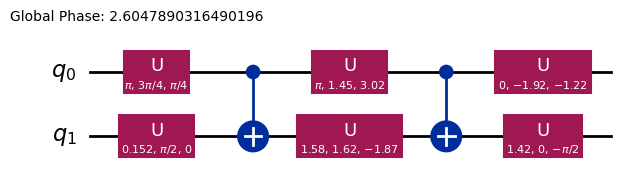

In [2]:
import numpy as np
CZ = np.asarray([[1,0,0,0],
                [0,1,0,0],
                [0,0,1,0],
                [0,0,0,-1]])
vec = np.asarray([0,0,1,0])

from qiskit.circuit.library import CXGate, CZGate, RZZGate

CX = CXGate().to_matrix()
CZ = CZGate().to_matrix()
RZZ = RZZGate(0.3).to_matrix()

from qiskit.synthesis import TwoQubitBasisDecomposer
from qiskit.quantum_info import Operator
from qiskit.circuit.library import CXGate

basis = CXGate()
decomposer = TwoQubitBasisDecomposer(CXGate())

import numpy as np
from qiskit.quantum_info import random_unitary

U = random_unitary(4)  # 4x4 = 2-qubit unitary
# Decompose
circ = decomposer(RZZ)
circ.draw('mpl', fold=-1)


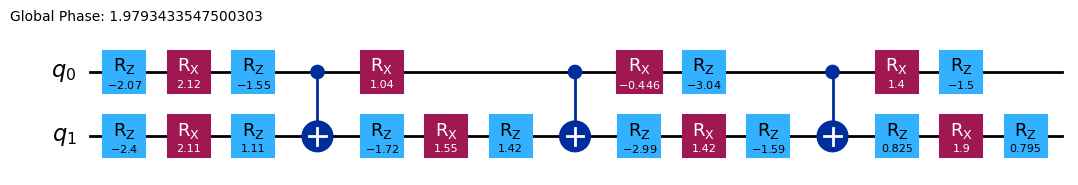

In [20]:
from qiskit import transpile

# Force decomposition into Rotation gates (Ry, Rz) instead of generic U
# This might make the parameter count clearer (1 param per gate) 
# but increases gate count.
transpiled_circ = transpile(circ, basis_gates=['cx', 'rz', 'rx'], optimization_level=3)
transpiled_circ.draw('mpl', fold=-1)


In [22]:
import pennylane as qml

from qiskit.quantum_info import random_unitary

U = random_unitary(4)
U.to_matrix()

instructions = qml.ops.two_qubit_decomposition(U.to_matrix(), wires=[0,1])
for op in instructions:
    print(op.name)
    print(op.parameters)

QubitUnitary
[array([[ 0.21145103+0.46119612j, -0.48695814+0.71095596j],
       [ 0.48695814+0.71095596j,  0.21145103-0.46119612j]])]
QubitUnitary
[array([[-0.01719559+0.11579087j,  0.5374312 +0.8351434j ],
       [-0.5374312 +0.8351434j , -0.01719559-0.11579087j]])]
CNOT
[]
RZ
[np.float64(0.5076973033764388)]
RY
[np.float64(1.5319707086552503)]
CNOT
[]
RY
[np.float64(1.9798937858744838)]
CNOT
[]
QubitUnitary
[array([[ 0.35394944+0.91544509j,  0.16551361+0.09636038j],
       [-0.16551361+0.09636038j,  0.35394944-0.91544509j]])]
QubitUnitary
[array([[ 0.80273135+0.03111259j, -0.53979165+0.25155389j],
       [ 0.53979165+0.25155389j,  0.80273135-0.03111259j]])]
GlobalPhase
[np.float64(-0.47652530062326376)]


In [18]:
single_q_gate = {}
for instr in circ.data:
    op = instr.operation
    qubits = instr.qubits
    if op.num_qubits == 1:
        U = op.to_matrix()
        print(f"Single-qubit gate: {op.name} on qubit {qubits[0]}  params = {op.params}")
        print(U)
    elif op.num_qubits == 2:
        print(f"Two-qubit gate: {op.name} on qubits {[q for q in qubits]}")


Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=0>  params = [3.141592653589793, 2.356194490192345, 0.7853981633974483]
[[ 6.12323400e-17+0.00000000e+00j -7.07106781e-01-7.07106781e-01j]
 [-7.07106781e-01+7.07106781e-01j -6.12323400e-17+7.49879891e-33j]]
Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=1>  params = [0.15207143187806368, 1.570796326794893, 3.552713678800501e-15]
[[ 9.97110677e-01+0.00000000e+00j -7.59624713e-02-2.69872911e-16j]
 [ 2.74524271e-16+7.59624713e-02j  6.10554200e-17+9.97110677e-01j]]
Two-qubit gate: cx on qubits [<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]
Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=0>  params = [3.141592653589793, 1.4480296506245018, 3.0188259774193975]
[[ 6.12323400e-17+0.00000000e+00j  9.92473632e-01-1.22458526e-01j]
 [ 1.22458526e-01+9.92473632e-01j -1.48839724e-17-5.93958485e-17j]]
Single-qubit gate: u on qubit <Qubit register=(2, "q"), index=1>  params = [1.5774841

In [2]:
import numpy as np
import plotly.graph_objects as go

# Points
I       = (0, 0, 0)
CNOT    = (np.pi/4, 0, 0)
iSWAP   = (np.pi/4, np.pi/4, 0)
SWAP    = (np.pi/4, np.pi/4, np.pi/4)
SWAP_dg = (np.pi/4, np.pi/4, -np.pi/4)
SQiSW   = (np.pi/8, np.pi/8, 0)

points = {
    "I(0,0,0)": I,
    "CNOT(π/4,0,0)": CNOT,
    "iSWAP(π/4,π/4,0)": iSWAP,
    "SWAP(π/4,π/4,π/4)": SWAP,
    "SWAP†(π/4,π/4,-π/4)": SWAP_dg,
    "SQiSW(π/8,π/8,0)": SQiSW,
}

fig = go.Figure()

# Scatter points with labels
for name, (x, y, z) in points.items():
    fig.add_trace(go.Scatter3d(
        x=[x], y=[y], z=[z],
        mode="markers+text",
        text=[name],
        textposition="top center"
    ))

# Helper to add line segments
def add_edge(p1, p2, dash=False):
    (x1,y1,z1), (x2,y2,z2) = p1, p2
    fig.add_trace(go.Scatter3d(
        x=[x1, x2], y=[y1, y2], z=[z1, z2],
        mode="lines",
        line=dict(dash="dash" if dash else "solid")
    ))

# Outer edges (like in the figure)
add_edge(I, CNOT)
add_edge(I, iSWAP)
add_edge(I, SWAP)
add_edge(CNOT, iSWAP)
add_edge(CNOT, SWAP)
add_edge(iSWAP, SWAP)
add_edge(I, SWAP_dg)
add_edge(SWAP_dg, iSWAP)
add_edge(SWAP_dg, SWAP)

# Internal dashed lines
add_edge(iSWAP, CNOT, dash=True)     # "B" line
add_edge(SWAP_dg, SQiSW, dash=True)  # line to SQiSW

fig.update_layout(
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
        xaxis=dict(range=[0, np.pi/4*1.1]),
        yaxis=dict(range=[-np.pi/4*1.1, np.pi/4*1.1]),
        zaxis=dict(range=[-np.pi/4*1.1, np.pi/4*1.1]),
    ),
    width=800,
    height=600
)

# color plane 
plane_extent = np.pi / 4 * 1.1
plane_x = np.array([[0, plane_extent], [0, plane_extent]])
plane_y = np.array([[-plane_extent, -plane_extent], [plane_extent, plane_extent]])
plane_z = np.zeros_like(plane_x)

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    showscale=False,
    opacity=0.35,
    colorscale=[[0, "lightsteelblue"], [1, "lightsteelblue"]],
    hoverinfo="skip"
))

fig.show()


In [1]:
a = (1,2)
b  = (3,4)
c = a + b

In [9]:
import pennylane as qml
import numpy as np
from scipy.linalg import expm

# Pauli matrices
X = np.array([[0, 1],
              [1, 0]], dtype=complex)
Y = np.array([[0, -1j],
              [1j, 0]], dtype=complex)
Z = np.array([[1, 0],
              [0, -1]], dtype=complex)

# Heisenberg couplings (choose them nonzero → evolution is entangling for generic t)
J = 1.
h = 1.

# Two-body Heisenberg Hamiltonian
H = J * np.kron(Z, Z) + h * (np.kron(np.eye(2),X) + np.kron(X, np.eye(2)))

# Time evolution operator U = exp(-i H t)
t = 0.25  # example time; for generic t this is entangling
U = expm(-1j * t * H)

qml.ops.two_qubit_decomposition(U, wires=[0,1])


[QubitUnitary(array([[ 6.27805346e-16-9.91878572e-01j, -1.27188439e-01-1.68463204e-16j],
        [ 1.27188439e-01-1.68463204e-16j,  6.27805346e-16+9.91878572e-01j]]), wires=[0]),
 QubitUnitary(array([[ 0.70136406+0.70136406j,  0.08993581-0.08993581j],
        [-0.08993581-0.08993581j,  0.70136406-0.70136406j]]), wires=[1]),
 CNOT(wires=[1, 0]),
 RZ(np.float64(-1.0813331968016464), wires=[0]),
 RY(np.float64(1.5707963267948895), wires=[1]),
 CNOT(wires=[0, 1]),
 RY(np.float64(1.560259456787794), wires=[1]),
 CNOT(wires=[1, 0]),
 QubitUnitary(array([[ 0.08993581-0.08993581j, -0.70136406+0.70136406j],
        [ 0.70136406+0.70136406j,  0.08993581+0.08993581j]]), wires=[0]),
 QubitUnitary(array([[ 2.46448494e-16-1.27188439e-01j, -9.91878572e-01-1.22705649e-16j],
        [ 9.91878572e-01-1.85909755e-16j, -2.46448494e-16+1.27188439e-01j]]), wires=[1]),
 GlobalPhase(np.float64(-0.7853981633972758), wires=[])]

In [22]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit.circuit.library import UnitaryGate  # <--- Essential Import
from qiskit.circuit.library import UGate

# 1. Define your constants
t = 1.5   
J = 1.2  
h0_arr = [5,1,-1, -5]
h1_arr = [5,1,-1, -5]

for h0 in h0_arr:
    for h1 in h1_arr:
        print("\n\n")
        print(f"h0: {h0}\n")
        print(f"h1: {h1}\n")

        # 2. Construct the Hamiltonian
        # H = J(Z1 Z0) + h0(X0) + h1(X1)
        H = SparsePauliOp.from_list([
            ("ZZ", J),
            ("IX", h0),
            ("XI", h1)
        ])

        # 3. Calculate the Target Unitary U = exp(-itH)
        matrix_H = H.to_matrix()
        U_matrix = expm(-1j * t * matrix_H)

        # 4. Perform the KAK (Weyl) Decomposition
        weyl_decomp = TwoQubitWeylDecomposition(U_matrix)

        # 5. Extract the interaction coefficients
        a, b, c = weyl_decomp.a, weyl_decomp.b, weyl_decomp.c

        print("Weyl Coordinates:")
        print(f"a (XX): {a:.4f}")
        print(f"b (YY): {b:.4f}")
        print(f"c (ZZ): {c:.4f}")
        print("-" * 30)

        # 6. Construct the Circuit
        qc = QuantumCircuit(2)

        # FIX: Wrap the numpy arrays in UnitaryGate()
        # K2 gates (applied first in time, rightmost in matrix mult)
        qc.append(UnitaryGate(weyl_decomp.K2l), [1]) 
        qc.append(UnitaryGate(weyl_decomp.K2r), [0]) 

        # -- Interaction 1: The 'a' term (XX interaction) --
        if abs(a) > 1e-10:
            qc.h([0, 1])
            qc.rzz(-2 * a, 0, 1) 
            qc.h([0, 1])

        # -- Interaction 2: The 'b' term (YY interaction) --
        if abs(b) > 1e-10:
            qc.rx(np.pi/2, [0, 1])
            qc.rzz(-2 * b, 0, 1)
            qc.rx(-np.pi/2, [0, 1]) 

        # -- Interaction 3: The 'c' term (ZZ interaction) --
        if abs(c) > 1e-10:
            qc.rzz(-2 * c, 0, 1)

        # FIX: Wrap the numpy arrays in UnitaryGate()
        # K1 gates (applied last in time, leftmost in matrix mult)
        qc.append(UnitaryGate(weyl_decomp.K1l), [1])
        qc.append(UnitaryGate(weyl_decomp.K1r), [0])

        # 7. Final decomposition 
        # We optimize to merge the UnitaryGates with the rotation helpers
        final_circ = transpile(qc, basis_gates=['rzz', 'rx', 'ry'], optimization_level=3)

        print(f"Total Rzz gates used: {final_circ.count_ops().get('rzz', 0)}")
        # \todo print the parameters of U3.
        print("\nU / U3 gate parameters in final_circ:")
        for instr in final_circ.data:
            op = instr.operation
            if isinstance(op, UGate) or op.name in ("rx", "ry"):
                theta = op.params
                print(f"{op.name} gate on qubits {instr.qubits}:")
                print(f"  θ = {theta}")
                print("---")

    # print("\nCircuit Diagram:")
    # print(final_circ.draw(output='text', idle_wires=False))




h0: 5

h1: 5

Weyl Coordinates:
a (XX): 0.7045
b (YY): 0.6371
c (ZZ): 0.0000
------------------------------
Total Rzz gates used: 2

U / U3 gate parameters in final_circ:
rx gate on qubits (<Qubit register=(2, "q"), index=0>,):
  θ = [2.843082000124449]
---
rx gate on qubits (<Qubit register=(2, "q"), index=1>,):
  θ = [2.843082000124449]
---
rx gate on qubits (<Qubit register=(2, "q"), index=0>,):
  θ = [1.5707963267948966]
---
rx gate on qubits (<Qubit register=(2, "q"), index=1>,):
  θ = [1.5707963267948966]
---
rx gate on qubits (<Qubit register=(2, "q"), index=0>,):
  θ = [1.2722856733295522]
---
rx gate on qubits (<Qubit register=(2, "q"), index=1>,):
  θ = [1.272285673329554]
---



h0: 5

h1: 1

Weyl Coordinates:
a (XX): 0.0267
b (YY): 0.0212
c (ZZ): 0.0000
------------------------------
Total Rzz gates used: 2

U / U3 gate parameters in final_circ:
rx gate on qubits (<Qubit register=(2, "q"), index=0>,):
  θ = [-0.13007086879614604]
---
ry gate on qubits (<Qubit register=(2

In [2]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit.circuit.library import UnitaryGate  # <--- Essential Import
from qiskit.circuit.library import UGate

# 1. Define your constants
t = 1.5   
J = 1.2  
h0 = 5.
h1 = 5.

# 2. Construct the Hamiltonian
# H = J(Z1 Z0) + h0(X0) + h1(X1)
H = SparsePauliOp.from_list([
    ("ZZ", J),
    ("IX", h0),
    ("XI", h1)
])

# 3. Calculate the Target Unitary U = exp(-itH)
matrix_H = H.to_matrix()
U_matrix = expm(-1j * t * matrix_H)

# 4. Perform the KAK (Weyl) Decomposition
weyl_decomp = TwoQubitWeylDecomposition(U_matrix)

# 5. Extract the interaction coefficients
a, b, c = weyl_decomp.a, weyl_decomp.b, weyl_decomp.c

print("Weyl Coordinates:")
print(f"a (XX): {a:.4f}")
print(f"b (YY): {b:.4f}")
print(f"c (ZZ): {c:.4f}")
print("-" * 30)

# 6. Construct the Circuit
qc = QuantumCircuit(2)

# FIX: Wrap the numpy arrays in UnitaryGate()
# K2 gates (applied first in time, rightmost in matrix mult)
qc.append(UnitaryGate(weyl_decomp.K2l), [1]) 
qc.append(UnitaryGate(weyl_decomp.K2r), [0]) 

# -- Interaction 1: The 'a' term (XX interaction) --
if abs(a) > 1e-10:
    qc.h([0, 1])
    qc.rzz(-2 * a, 0, 1) 
    qc.h([0, 1])

# -- Interaction 2: The 'b' term (YY interaction) --
if abs(b) > 1e-10:
    qc.rx(np.pi/2, [0, 1])
    qc.rzz(-2 * b, 0, 1)
    qc.rx(-np.pi/2, [0, 1]) 

# -- Interaction 3: The 'c' term (ZZ interaction) --
if abs(c) > 1e-10:
    qc.rzz(-2 * c, 0, 1)

# FIX: Wrap the numpy arrays in UnitaryGate()
# K1 gates (applied last in time, leftmost in matrix mult)
qc.append(UnitaryGate(weyl_decomp.K1l), [1])
qc.append(UnitaryGate(weyl_decomp.K1r), [0])

# 7. Final decomposition 
# We optimize to merge the UnitaryGates with the rotation helpers
# final_circ = transpile(qc, basis_gates=['rzz', 'ry', 'rx'], optimization_level=3)
final_circ = transpile(qc, basis_gates=['rzz', 'u3'], optimization_level=3)

print(f"Total Rzz gates used: {final_circ.count_ops().get('rzz', 0)}")
# \todo print the parameters of U3.
print("\nU / U3 gate parameters in final_circ:")
for instr in final_circ.data:
    op = instr.operation
    if isinstance(op, UGate) or op.name in ("u", "u3"):
        theta, phi, lam = op.params
        print(f"U gate on qubits {instr.qubits}:")
        print(f"  θ = {theta}")
        print(f"  φ = {phi}")
        print(f"  λ = {lam}")
        print("---")

print("\nCircuit Diagram:")
print(final_circ.draw(output='text', idle_wires=False, fold=-1))

Weyl Coordinates:
a (XX): 0.7045
b (YY): 0.6371
c (ZZ): 0.0000
------------------------------
Total Rzz gates used: 2

U / U3 gate parameters in final_circ:
U gate on qubits (<Qubit register=(2, "q"), index=0>,):
  θ = 0.298510653465346
  φ = -1.5707963267948988
  λ = -1.5707963267948948
---
U gate on qubits (<Qubit register=(2, "q"), index=1>,):
  θ = 0.2985106534653456
  φ = -1.5707963267948961
  λ = -1.570796326794897
---
U gate on qubits (<Qubit register=(2, "q"), index=0>,):
  θ = 1.5707963267948966
  φ = 0.0
  λ = -1.570796326794897
---
U gate on qubits (<Qubit register=(2, "q"), index=1>,):
  θ = 1.5707963267948966
  φ = 0.0
  λ = -1.570796326794897
---
U gate on qubits (<Qubit register=(2, "q"), index=0>,):
  θ = 1.869306980260238
  φ = 1.5707963267948966
  λ = -3.141592653589793
---
U gate on qubits (<Qubit register=(2, "q"), index=1>,):
  θ = 1.8693069802602378
  φ = 1.5707963267948966
  λ = -3.141592653589793
---

Circuit Diagram:
global phase: π
     ┌──────────────────────

In [44]:
# 8. Check: does the decomposed circuit match U_matrix (up to global phase)?
def embed_single_qubit_gate(gate_2x2, qubit_index):
    """Return 4x4 matrix of a 1-qubit gate embedded in 2-qubit space."""
    I = np.eye(2, dtype=complex)
        # Gate on the most significant qubit (q0)
    if qubit_index == 1:
        return np.kron(gate_2x2, I)
    elif qubit_index == 0:
        # Gate on the least significant qubit (q1)
        return np.kron(I, gate_2x2)
    else:
        raise ValueError("Only 2-qubit circuits supported here.")

# Map circuit qubits to indices 0/1 in our matrix convention
# (In this simple 2-qubit case, this is trivial, but we keep it explicit.)
qubit_index_map = {final_circ.qubits[0]: 0, final_circ.qubits[1]: 1}

U_reconstructed = np.eye(4, dtype=complex)

for instr in final_circ.data:
    op = instr.operation
    qargs = instr.qubits
    num_q = op.num_qubits

    if num_q == 1:
        # 2x2 matrix of the gate
        G = Operator(op).data
        q_idx = qubit_index_map[qargs[0]]
        U_gate_full = embed_single_qubit_gate(G, q_idx)
    elif num_q == 2:
        # 4x4 matrix directly
        U_gate_full = Operator(op).data
    else:
        raise ValueError("Unexpected gate with num_qubits != 1 or 2.")

    # Compose: later gates multiply on the left
    U_reconstructed = U_gate_full @ U_reconstructed
    print(op.params)

# 9. Compare U_reconstructed with the target U_matrix (up to global phase)

# Align global phase between U_reconstructed and U_matrix
overlap = np.vdot(U_matrix.flatten(), U_reconstructed.flatten())
phase = np.exp(1j * np.angle(overlap))
U_aligned = U_reconstructed * phase.conjugate()

diff = U_aligned - U_matrix
max_abs_diff = np.max(np.abs(diff))
fro_norm = np.linalg.norm(diff, 'fro')

print("\n=== Explicit Matrix Composition Check ===")
print(f"Max |ΔU_ij| (up to global phase): {max_abs_diff:.3e}")
print(f"Frobenius norm ||ΔU||_F:          {fro_norm:.3e}")
print(f"Global phase (radians):           {np.angle(phase):.6f}")
print("Match within 1e-10 tolerance?     ", max_abs_diff < 1e-10)


[0.298510653465346, -1.5707963267948988, -1.5707963267948948]
[0.2985106534653456, -1.5707963267948961, -1.570796326794897]
[-1.4089523766083971]
[1.5707963267948966, 0.0, -1.570796326794897]
[1.5707963267948966, 0.0, -1.570796326794897]
[-1.2742329305711897]
[1.869306980260238, 1.5707963267948966, -3.141592653589793]
[1.8693069802602378, 1.5707963267948966, -3.141592653589793]

=== Explicit Matrix Composition Check ===
Max |ΔU_ij| (up to global phase): 9.421e-16
Frobenius norm ||ΔU||_F:          1.771e-15
Global phase (radians):           3.141593
Match within 1e-10 tolerance?      True
